In [1]:
%matplotlib widget 
import numpy as np
# from myptv.tracking_mod import tracker_four_frames
# from myptv.tracking_mod2 import tracker_four_frames
from myptv.tracking_mod3 import tracker_four_frames
from myptv.makePlots.plot_trajectories import plot_trajectories, animate_trajectories
from myptv.traj_smoothing_mod import smooth_trajectories
from myptv.traj_stitching_mod import traj_stitching
import matplotlib.pyplot as plt
import os


In [3]:
fname_loc = os.path.join(os.getcwd(), "data", "D400_TP_Swl_r2_loc_01-25_09-25_reg")
t4f = tracker_four_frames(fname=fname_loc, 
                          mean_flow=np.array([0.0, 0, 0]), 
                          d_max=0.2, 
                          dv_max=0.1, 
                          z_weight=0.01, 
                          dz_link_max=1.0,
                         )

t4f.track_all_frames()

fname_tr = fname_loc+'_tr'
t4f.save_results(fname_tr)


found 3415 trajectories (avg. length = 11.9)
four frame links: 33751
nearest neighbour links: 3415


plotted 1749 trajectories


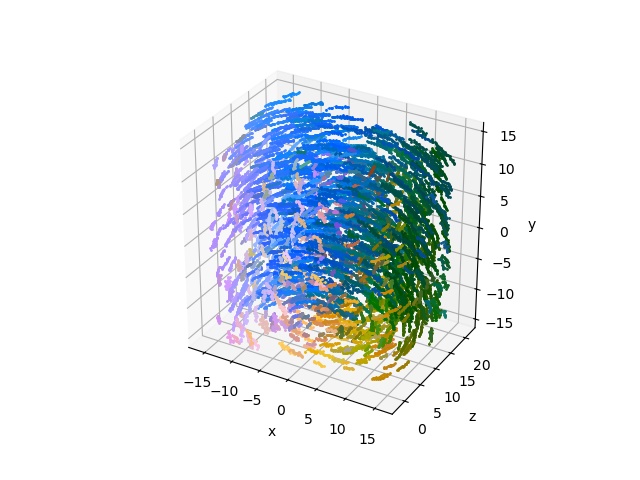

In [4]:
plot_trajectories(fname=fname_tr, min_length=12)

In [5]:
fname_tr_sm = fname_tr + '_sm'

sm = smooth_trajectories(traj_list=t4f.return_connected_particles(),
                         window=7, 
                         polyorder=1,
                         min_traj_length=5,
                         repetitions=7)  # 10

sm.smooth()
sm.save_results(fname_tr_sm)



100%|██████████████████████████████████████████████████████████████████████████████| 3415/3415 [01:15<00:00, 45.14it/s]



smoothed samples: 23187
too short to smooth: 2137
single samples: 2966


plotted 1843 trajectories


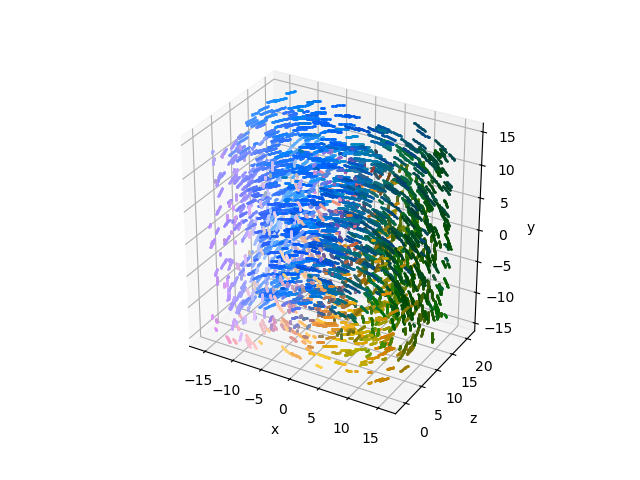

In [6]:
plot_trajectories(fname=fname_tr_sm, min_length=5)

In [73]:
# fname_tr_sm_st = fname_tr_sm + '_st'
# st = traj_stitching(np.array(sm.smoothed_trajs), 1, 0.4)
# st.stitch_trajectories()
# st.save_results(fname_tr_sm_st)

In [75]:
# plot_trajectories(fname=fname_tr_sm_st, min_length=10)

In [76]:
# ani = animate_trajectories(fname=fname_tr_sm, min_length=3, rotation_rate=0.5, tail_length=10)
# ani.animate()

# visualize linking results

In [7]:
# fre = 2e3/4 # frame rate
# fre = 2e3/2 # frame rate
fre = 2e3/1 # frame rate

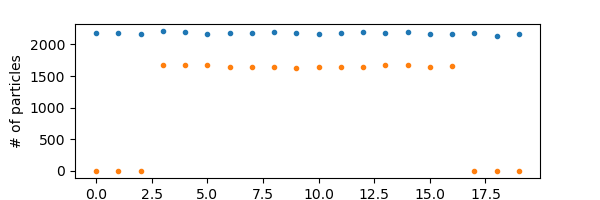

In [8]:
# read tr file
from numpy import savetxt

tr_data = np.loadtxt(fname_tr)
times = np.unique(tr_data[:, -1])
# print(times)
tr_particles = []
tr_pnum = []
for t in times:
    ps = tr_data[tr_data[:, -1]==t, :]
    tr_particles.append(ps)
    tr_pnum.append(ps.shape[0])

# read sm file
sm_data = np.loadtxt(fname_tr + '_sm')
dt = 1/fre *1e3 # from s to ms
sm_data = sm_data[sm_data[:, 4]!=0, :]  # 0 velocity means the particle is excluded in smoothing
sm_data[:, 4:7] = sm_data[:, 4:7]/dt  # velocity correction
sm_data[:, 7:10] = sm_data[:, 7:10]*1e3/(dt**2)  # acceleration correction

# save 
fmt = ['%d', '%.9g', '%.9g', '%.9g', '%.9g', '%.9g', '%.9g', '%.9g',
        '%.9g', '%.9g', '%d']

savetxt(fname_tr + '_sm_', sm_data, fmt=fmt, delimiter='\t')  # result with velocity correction 


sm_particles = []
sm_pnum = []
for t in times:
    ps = sm_data[sm_data[:, -1]==t, :]
    sm_particles.append(ps)
    sm_pnum.append(ps.shape[0])

plt.figure(figsize=(6, 2))
plt.plot(tr_pnum, '.')
plt.plot(sm_pnum, '.')
plt.xlabel('frame idx')
plt.ylabel('# of particles')
plt.show()


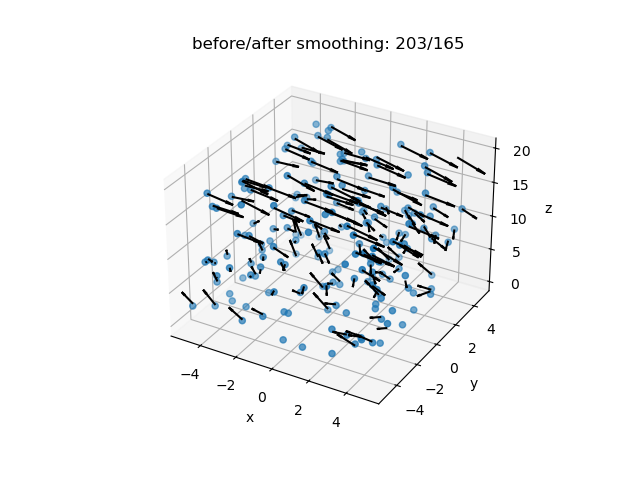

In [9]:
# demo
idx = 11

zmin = 0.0
zmax = 20.0
xy05 = 5 # mm

ps0 = tr_particles[idx].copy()
ps0 = ps0[(ps0[:, 3] > zmin) & (ps0[:, 3] < zmax), :]
ps0 = ps0[(ps0[:, 1] > -xy05) & (ps0[:, 1] < xy05) & (ps0[:, 2] > -xy05) & (ps0[:, 2] < xy05), :]

ps1 = sm_particles[idx].copy()
ps1 = ps1[(ps1[:, 3] > zmin) & (ps1[:, 3] < zmax), :]
ps1 = ps1[(ps1[:, 1] > -xy05) & (ps1[:, 1] < xy05) & (ps1[:, 2] > -xy05) & (ps1[:, 2] < xy05), :]


fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(ps0[:, 1], ps0[:, 2], ps0[:, 3])
ax.quiver(ps1[:, 1], ps1[:, 2], ps1[:, 3], ps1[:, 4], ps1[:, 5], ps1[:, 5], length=5, color='black')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(f'before/after smoothing: {ps0.shape[0]}/{ps1.shape[0]}')
plt.show()


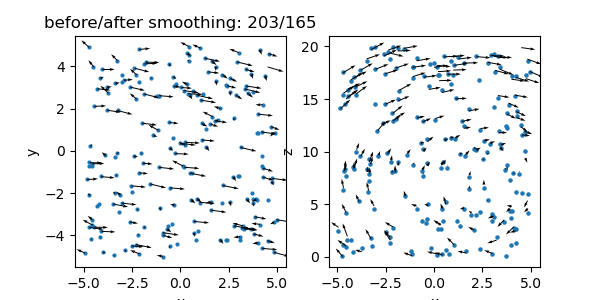

In [10]:
fig = plt.figure(figsize=(6, 3))
ax1 = fig.add_subplot(121)
ax1.scatter(ps0[:, 1], ps0[:, 2], s=4)
ax1.quiver(ps1[:, 1], ps1[:, 2], ps1[:, 4], ps1[:, 5])
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'before/after smoothing: {ps0.shape[0]}/{ps1.shape[0]}')

ax2 = fig.add_subplot(122)
ax2.scatter(ps0[:, 1], ps0[:, 3], s=5)
ax2.quiver(ps1[:, 1], ps1[:, 3], ps1[:, 4], ps1[:, 6])
ax2.set_xlabel('x')
ax2.set_ylabel('z')
plt.show()

# save dat files for CCM 

In [15]:
# from pathlib import Path
# import shutil
# from p1 import export_psfe_to_dat

# outdir = 'dat_output'
# dir_path = Path(outdir)
# if dir_path.exists():
#     shutil.rmtree(dir_path)

# export_psfe_to_dat(sm_particles, outdir)
# # export_psfe_to_dat(sm_particles_, outdir)

done
